In [3]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('/content/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  
Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and

In [4]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


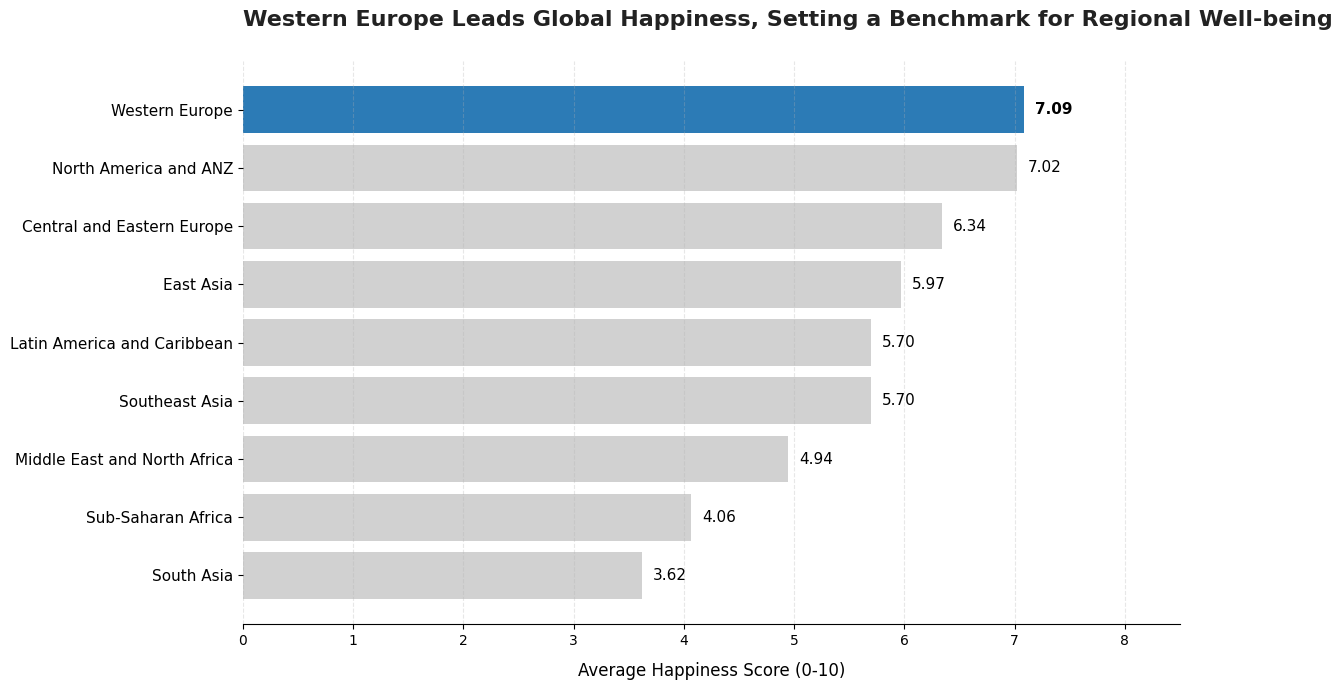

In [5]:
##Step 2:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we sort descending so the happiest region is at the top
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score', ascending=True)) # ascending=True for barh to plot highest at the top

# Create the plot
plt.figure(figsize=(12, 7))

# Design Choice: Use a distinct color for the top region to draw the eye immediately (SWD principle)
colors = ['#d1d1d1' if x < region_avg['Happiness_Score'].max() else '#2c7bb6' for x in region_avg['Happiness_Score']]
bars = plt.barh(region_avg['Region'], region_avg['Happiness_Score'], color=colors)

# Rule: Insight title (answers "which region stands out and why does it matter?")
plt.title('Western Europe Leads Global Happiness, Setting a Benchmark for Regional Well-being',
          fontsize=16, fontweight='bold', pad=25, loc='left', color='#222222')

# Rule: Zero baseline on x-axis (explicitly starting from 0)
plt.xlim(0, 8.5)

# Styling and Professional Touches
plt.xlabel('Average Happiness Score (0-10)', fontsize=12, labelpad=10)
plt.ylabel('') # Removed redundant label
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

# Design choice: Add direct labels for precision without cluttering the x-axis
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', fontsize=11, fontweight='bold' if width == region_avg['Happiness_Score'].max() else 'normal')

# Clean background (remove top and right spines)
sns.despine(left=True, bottom=False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")


Global average: 5.81


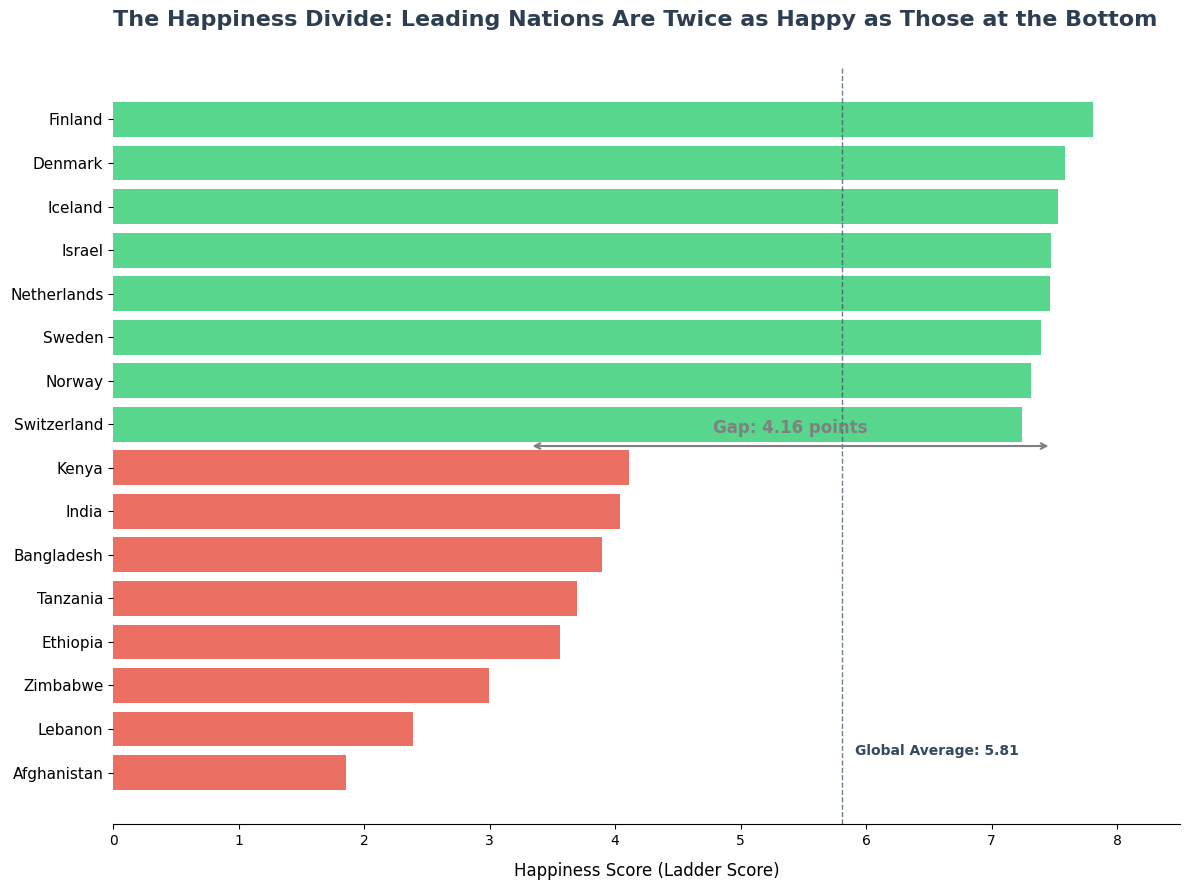

In [7]:
# Task 2 Step 1: Prepare the data (already done in your snippet)
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'
combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score', ascending=True)
global_avg = df['Happiness_Score'].mean()

# Step 2: Create the visualization
plt.figure(figsize=(12, 9))

# Rule: Use color to distinguish the two groups (Green for Top, Red for Bottom)
colors = ['#e74c3c' if g == 'Bottom 8' else '#2ecc71' for g in combined['Group']]
bars = plt.barh(combined['Country'], combined['Happiness_Score'], color=colors, alpha=0.8)

# Rule: Insight title that tells the story of the gap
plt.title('The Happiness Divide: Leading Nations Are Twice as Happy as Those at the Bottom',
          fontsize=16, fontweight='bold', pad=30, loc='left', color='#2c3e50')

# Rule: Every bar chart must have a zero baseline
plt.xlim(0, 8.5)

# Stretch goal: Vertical reference line showing the global average
plt.axvline(global_avg, color='#34495e', linestyle='--', linewidth=1, alpha=0.7)
plt.text(global_avg + 0.1, 0.5, f'Global Average: {global_avg:.2f}',
         color='#34495e', fontweight='bold', verticalalignment='center')

# Rule: Add a visual annotation that emphasises the gap
# We will draw a line indicating the distance between the two group averages
avg_top = top8['Happiness_Score'].mean()
avg_bottom = bottom8['Happiness_Score'].mean()
plt.annotate('', xy=(avg_bottom, 7.5), xytext=(avg_top, 7.5),
             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
plt.text((avg_top + avg_bottom)/2, 7.8, f"Gap: {avg_top - avg_bottom:.2f} points",
         ha='center', color='gray', fontsize=12, fontweight='bold')

# Styling for professional quality
plt.xlabel('Happiness Score (Ladder Score)', fontsize=12, labelpad=10)
plt.ylabel('') # Remove y-label as country names are sufficient
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)
sns.despine(left=True, bottom=False) # Clean background

plt.tight_layout()
plt.show()

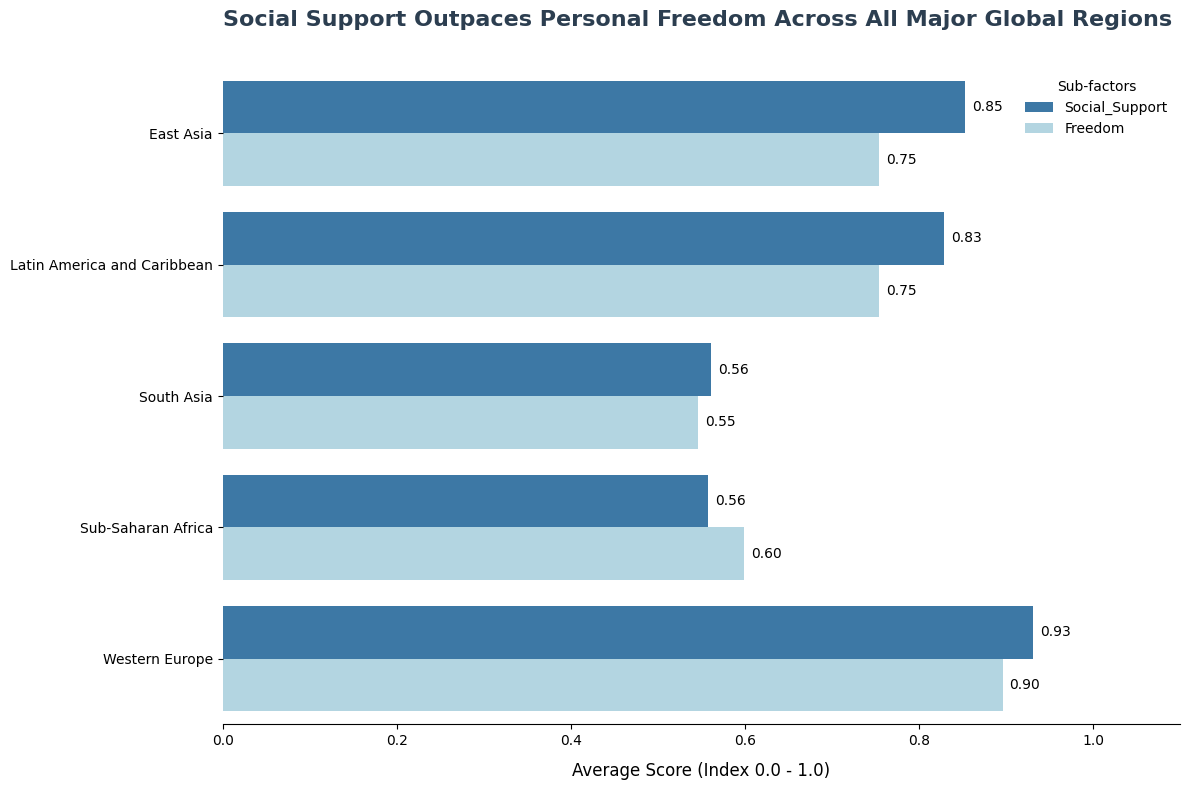

In [8]:
# Step 1: Filter for the requested regions
target_regions = ['Western Europe', 'Latin America and Caribbean', 'East Asia', 'Sub-Saharan Africa', 'South Asia']
df_filtered = df[df['Region'].isin(target_regions)]

# Step 2: Compute averages for Social Support and Freedom
# These are chosen because they share a similar scale (0.0 to 1.0)
grouped_data = df_filtered.groupby('Region')[['Social_Support', 'Freedom']].mean().reset_index()

# Melt the data for Seaborn's grouped bar format
melted_data = grouped_data.melt(id_vars='Region', var_name='Factor', value_name='Average Score')

# Step 3: Build the chart
plt.figure(figsize=(12, 8))

# Rule: Use colour meaningfully (Dark blue for support, light blue for freedom)
palette = {'Social_Support': '#2c7bb6', 'Freedom': '#abd9e9'}
ax = sns.barplot(data=melted_data, x='Average Score', y='Region', hue='Factor', palette=palette)

# Rule: Insight title
plt.title('Social Support Outpaces Personal Freedom Across All Major Global Regions',
          fontsize=16, fontweight='bold', pad=30, loc='left', color='#2c3e50')

# Rule: Zero baseline
plt.xlim(0, 1.1)

# Professional touches
plt.xlabel('Average Score (Index 0.0 - 1.0)', fontsize=12, labelpad=10)
plt.ylabel('')
plt.legend(title='Sub-factors', frameon=False, bbox_to_anchor=(1, 1))

# Design choice: Add data labels to make the gap between factors explicit
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.2f}',
                    (width, p.get_y() + p.get_height() / 2),
                    xytext=(5, 0),
                    textcoords='offset points',
                    va='center', fontsize=10)

sns.despine(left=True)
plt.tight_layout()
plt.show()